---
title: "Inferencia Neymaniana"
description: "Inferencia Neymaniana en Experimentos Completamente Aleatorizados"
categories: [Causal Inference]
order: 3
---

In [2]:
from scipy.special import comb
import os
import pandas as pd
from statsmodels.stats.weightstats import ttest_ind
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from scipy.stats import expon

import os
if 'COLAB_GPU' in os.environ:
  from google.colab import drive
  drive.mount("/content/drive/")

  path = "/content/drive/MyDrive/Estudios/ding/data"
  df = pd.read_csv(os.path.join(path, "lalonde.csv"))

else:
  df = pd.read_csv("data/lalonde.csv")

# Inferencia Neymaniana en Experimentos Completamente Aleatorizados

## Cantidades de poblaciones finitas

<br>

**Definición: Cantidades de poblaciones finitas de resultados potenciales**

Consideremos un experimento con $n$ unidades, de las cuales a $n_1$ unidades se les aplicará el tratamiento y a $n_0$ se les aplicará el control, $n=n_1+n_0$. De esta forma tenemos las siguientes cantidades de poblaciones finitas:




 - Medias de resultados potenciales
$$\bar{Y}(1)=n^{-1}\sum_{i=1}^{n}Y_i(1);\space \space \space \bar{Y}(0)=n^{-1}\sum_{i=1}^{n}Y_i(0)$$

 - Varianzas de resultados potenciales
$$S^{2}(1)=(n-1)^{-1}\sum_{i=1}^{n}\{Y_i(1)-\bar{Y}(1)\}^{2};\space \space \space S^{2}(0)=(n-1)^{-1}\sum_{i=1}^{n}\{Y_i(0)-\bar{Y}(0)\}^{2}$$

 - Covarianzas de resultados potenciales
$$S(1,0)=(n-1)^{-1}\sum_{i=1}^{n}\{Y_i(1)-\bar{Y}(1)\}\{Y_i(0)-\bar{Y}(0)\}$$

 - Media de efectos causales
$$\tau = n^{-1}\sum_{i=1}^{n}\tau_i = \bar{Y}(1)- \bar{Y}(0)$$

 - Varianza de efectos causales

$$S^{2}(\tau)=(n-1)^{-1}\sum_{i=1}^{n}\{\tau_i-\tau\}^{2}$$



## Teorema de Neyman

<br>

**Definición: Cantidades muestrales basados en resultados observados**

 - Medias muestrales de resultados observados

$$\hat{Y}(1) = n_1^{-1}\sum_{i=1}^{n}Z_iY_i \space; \space\space\hat{Y}(0) = n_0^{-1}\sum_{i=1}^{n}(1-Z_i)Y_i$$

 - Varianzas muestrales de resultados observados

$$\hat{S}^2(1)=(n_1-1)^{-1}\sum_{i=1}^{n}Z_i\{Y_i-\hat{Y}(1)\}\space; \space\space\hat{S}^2(0)=(n_0-1)^{-1}\sum_{i=1}^{n}(1-Z_i)\{Y_i-\hat{Y}(0)\}$$

 - No existencia de $\hat{S}^2(0,1)$ y de ${S}^2(\tau)$

No existen estimadores de $\hat{S}^2(0,1)$ y de ${S}^2(\tau)$ porque no es posible observar al mismo tiempo los resultados potenciales $Y_i(1)$ y $Y_i(0)$ de cada unidad $i$.

<br>

**Teorema de Neyman**

Bajo un experimento completamente aleatorizado:

 1. El estimador de diferencia de medias $\hat\tau = \hat{Y}(1) - \hat{Y}(0)$ es insesgado para $\tau$:

 $$E(\hat\tau) = \tau$$

2. $\hat\tau$ tiene varianza

$$\begin{aligned}  var(\hat{\tau}) &= \frac{S^2(1)}{n_1} + \frac{S^2(0)}{n_0} - \frac{S^2(\tau)}{n} \\ &= \frac{n_0}{n_1n}S^2(1) + \frac{n_1}{n_0n}S^2(0)  + \frac{2}{n}S(0,1)\end{aligned}$$

3. El estimador de la varianza

$$\hat V = \frac{\hat{S}^2(1)}{n_1}+\frac{\hat{S}^2(0)}{n_0}$$

es conservador en el sentido de que

$$E(\hat V) - var(\hat \tau) = \frac{S^2(\tau)}{n} \geq 0$$

Donde la igualdad solo se cumple si y solo si $\tau_i = \tau$ para toda unidad $i$.


**Consideraciones especiales**

 - A pesar de que el estimador $\hat\tau$ es de diferencia de medias, la varianza no depende únicamente de las varianzas finitas de los efectos potenciales, sino también de la varianza finita de los efectos individuales.

  - En la prueba de aleatorización de Fisher, el vector $Y$ de resultados observados es el mismo para cualquier permutación, dada la hipótesis nula donde los resultados potenciales $Y_i(0)$ y $Y_i(1)$ son los mismos. Aquí en cambio, al no hacerse ese supuesto, $Y$ varía con cada permutación.


## Análisis de regresión de un experimento completamente aleatorizado

Es posible encontrar inferencia del efecto causal promedio $\tau$ basada en regresión lineal. El enfoque estándar es el de Mínimos Cuadrados Ordinarios (OLS) de los resultados observados sobre los indicadores de tratamiento y un intercepto:

$$Y_i = a + bZ_i$$
$$(\hat \alpha, \hat \beta) = \underset{(a,b)}{\operatorname{argmin}}\sum_{i=1}^{n}(Y_i - a - bZ_i)$$

En donde el estimador $\hat \beta$ es usado como el estimador del efecto causal promedio. Con esta especificación, se puede demostrar, aunque no aquí, que $\hat \beta$ es equivalente al estimador de diferencia de medias:

$$\hat \beta = \hat \tau$$

Sin embargo, el estimador de varianza de OLS es:

$$\hat V_{OLS}= \frac{n(n_1-1)}{(n-2)n_1n_0}S^2(1) + \frac{n(n_0-1)}{(n-2)n_1n_0}S^2(0) \approx \frac{S^2(1)}{n_0} + \frac{S^2(0)}{n_1}$$

difiere de $\hat V$ inclusive con valores grandes de $n_1$ y $n_0$.

Por tal motivo, podemos usar el estimador robusto de la varianza de Eicker-Huber-White (EHW) que sí es cercano a $\hat V$.

$$\hat V_{EHW}= \frac{\hat S^2(1)}{n_1}\frac{n_1-1}{n_1} + \frac{\hat S^2(0)}{n_0}\frac{n_0-1}{n_0} \approx \frac{S^2(1)}{n_1} + \frac{S^2(0)}{n_0}$$

Inclusive la variante HC2 es idéntica a $\hat V$.

## Ejemplos

Efecto causal promedio: 1.0


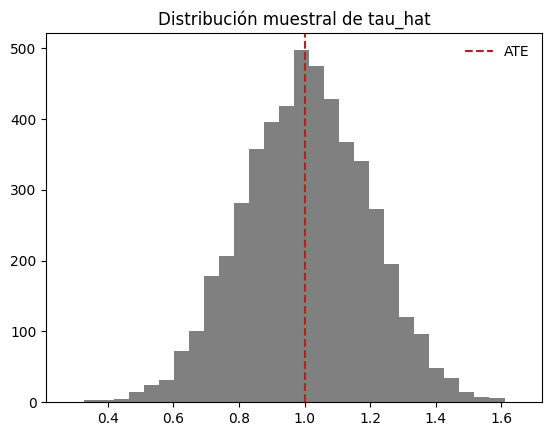

In [3]:
# Simulación

# Tamaño de población, tratamiento y control
n = 100
n1 = 60
n0 = n - n1

# Resultados potenciales
idx = np.arange(n)
y0 = expon.rvs(size=n, random_state=42)
y0 = np.sort(y0)[::-1]
y1 = y0 + 1

# Efecto causal promedio teórico (igual a 1 por la construcción de y1)
tau = np.mean(y1 - y0)
print("Efecto causal promedio:", tau)

# Generamos experimentos completamente aleatorizados
tau_hats = []
vars_tau = []
for i in range(5000):
  # Escogemos las unidades de tratamiento y control
  perm = np.random.permutation(idx)
  idx_treat = perm[:n1]
  idx_control =  perm[n1:]
  treat = y1[idx_treat]
  control = y0[idx_control]

  # Estimador insesgado del efecto causal promedio
  tau_hat = np.mean(treat) - np.mean(control)
  tau_hats.append(tau_hat)

  #

fig, ax = plt.subplots()
ax.hist(tau_hats, bins = 30, color = 'grey')
ax.set_title("Distribución muestral de tau_hat")
ax.axvline(x=tau, linestyle='--', color='firebrick', label='ATE')
ax.legend(frameon=False)

In [4]:
# Lalonde data
z = df["treat"]
y = df["re78"]

# Estimador del efecto causal promedio
tau_hat = np.mean(y[z==1]) - np.mean(y[z==0])
print("Estimador insesgado de efecto causal promedio (ATE):", np.round(tau_hat, 3))

# Varianza del estimador
n1 = np.sum(z)
n0 = z.shape[0] - n1
v_hat = np.var(y[z==1], ddof=1)/n1 + np.var(y[z==0], ddof=1)/n0
se_hat = np.sqrt(v_hat)
print("Error estándar del estimador de ATE:", np.round(se_hat, 3))

# estimador de OLS
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
Z = sm.add_constant(z)

model = sm.OLS(y,Z)
results = model.fit()
print("-"*50)
print("Estimador de OLS")
print("Coeficiente:", np.round(results.params.values[1], 3))
print("Error éstandar:", np.round(results.bse.values[1], 3))
print("Error éstandar EHW(0):", np.round(results.HC0_se.values[1], 4))
print("Error éstandar EHW(2):", np.round(results.HC2_se.values[1], 4))

Estimador insesgado de efecto causal promedio (ATE): 1794.343
Error estándar del estimador de ATE: 670.997
--------------------------------------------------
Estimador de OLS
Coeficiente: 1794.343
Error éstandar: 632.854
Error éstandar EHW(0): 669.3155
Error éstandar EHW(2): 670.9967
